 PROYECTO FINAL GRUPO 2
DataSet aplicarle todas las validaciones y evaluaciones de ML y como final investigar, utilizar y explicar una validacion que solo se aplique al contexto de su DataSet seleccionado.


In [105]:
#importacion de librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_curve, auc
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline

#Cargar dataser
df = pd.read_csv('credit_record.csv')


In [106]:
#Conversion de variable STATUS a numerico

df["STATUS_NUM"] = df["STATUS"].replace({
    'X': -1,   # Sin préstamo ese mes
    'C': 0,    # Crédito cerrado
    '0': 0,    # Al día
    '1': 1,    # 1-30 días atraso
    '2': 2,
    '3': 3,
    '4': 4,
    '5': 5
})

#Agrupar por Cliente(ID)
df_grouped = df.groupby("ID").agg({
    "STATUS_NUM": ["max", "mean", "sum"],
    "MONTHS_BALANCE": "count"
})

df_grouped.columns = ["max_status", "mean_status", "sum_status", "num_months"]
df_grouped = df_grouped.reset_index()
print("Dimensiones después de agrupar:", df_grouped.shape)


Dimensiones después de agrupar: (45985, 5)


C:\Users\danie\AppData\Local\Temp\ipykernel_3460\3730967496.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["STATUS_NUM"] = df["STATUS"].replace({


In [107]:
#Crear Variable Objetivo (TARGET

#Cliente riesgoso (1) si alguna vez tuvo mora >= 2
df_grouped["TARGET"] = (df_grouped["max_status"] >= 2).astype(int)

print("Distribución de clases:")
print(df_grouped["TARGET"].value_counts(normalize=True).map("{:.2%}".format))

Distribución de clases:
TARGET
0    98.55%
1     1.45%
Name: proportion, dtype: object


In [108]:

#Definir variables objetivo (X) y variable a predecir (y)
X = df_grouped.drop(['ID', 'TARGET', 'max_status', 'STATUS_NUM'], axis=1, errors='ignore')
y = df_grouped['TARGET']


In [109]:
#Entrenando el modelo
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
model = RandomForestClassifier(random_state=42)
scores = cross_val_score(model, X_train, y_train, cv=5)
print("Promedio de precision en validación cruzada:", scores.mean())




Promedio de precision en validación cruzada: 0.9894995406285203


In [110]:
#Creacion de pipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(random_state=42))
])

pipeline.fit(X_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2


In [111]:
#Validacion de validacion con el GridSearchCV y que todo este correcto
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10],
    'model__min_samples_split': [2, 5]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='f1'
)

grid.fit(X_train, y_train)

print("Mejores hiperparámetros:", grid.best_params_)
print("Mejor puntuación F1 en validación cruzada:", grid.best_score_)

Mejores hiperparámetros: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Mejor puntuación F1 en validación cruzada: 0.5831368841431444


In [112]:
#Evaluación del Mejor Modelo
from sklearn.metrics import classification_report, roc_curve, auc

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)
y_propa = best_model.predict_proba(X_test)[:, 1]



print("Reporte de clasificación:")
print(classification_report(y_test, y_pred))



Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     13602
           1       0.62      0.54      0.57       194

    accuracy                           0.99     13796
   macro avg       0.81      0.77      0.78     13796
weighted avg       0.99      0.99      0.99     13796



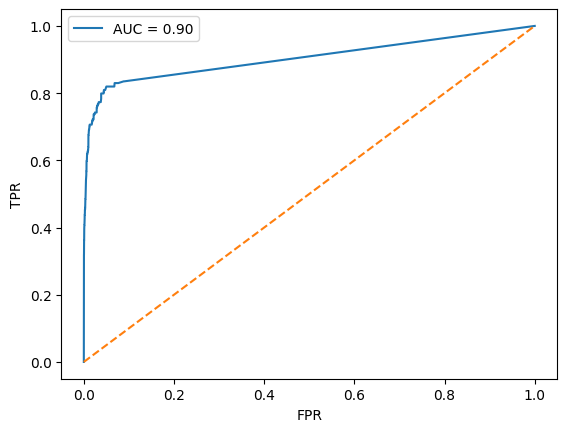

In [113]:
#Grafico
import matplotlib.pyplot as plt
fpr, tpr, _ = roc_curve(y_test, y_propa)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.show()


In [114]:
# Investigar como se usa el Threshold Moving Average (TMA).  Y cual es la metrica exclisuva de nuestro proyecto.

In [115]:
#Validacion de contexto: Ajuste de umbral (Threshold Moving Average - TMA)
# Si la probabilidad de mora es > 0.3 (en lugar de 0.5), lo rechazamos.

from sklearn.metrics import classification_report

print("Reporte de clasificación con umbral ajustado:")
print(classification_report(y_test, (y_propa > 0.3).astype(int)))



Reporte de clasificación con umbral ajustado:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     13602
           1       0.49      0.64      0.55       194

    accuracy                           0.99     13796
   macro avg       0.74      0.81      0.77     13796
weighted avg       0.99      0.99      0.99     13796



In [116]:
import numpy as np
thresholds = 0.3
y_custom = np.where(y_propa > thresholds, 1, 0)
print("Reporte de clasificación con umbral personalizado:")
print(classification_report(y_test, y_custom))

Reporte de clasificación con umbral personalizado:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     13602
           1       0.49      0.64      0.55       194

    accuracy                           0.99     13796
   macro avg       0.74      0.81      0.77     13796
weighted avg       0.99      0.99      0.99     13796

